# Latent Diffusion Models - Stable Diffusion

In [2]:
import torch.nn as nn
import torch.functional as F
from typing import Any
import torchview
from torch import Tensor
import torch

#### encode image -> diffuse laten space -> denoise the laten space with conditioning

LPIPS  - metric used to compare input and output similarity - perceptual difference/similarity - lower LPIPS better
github link - [github](https://github.com/richzhang/perceptualsimilarity)

In [19]:
# !pip install lpips

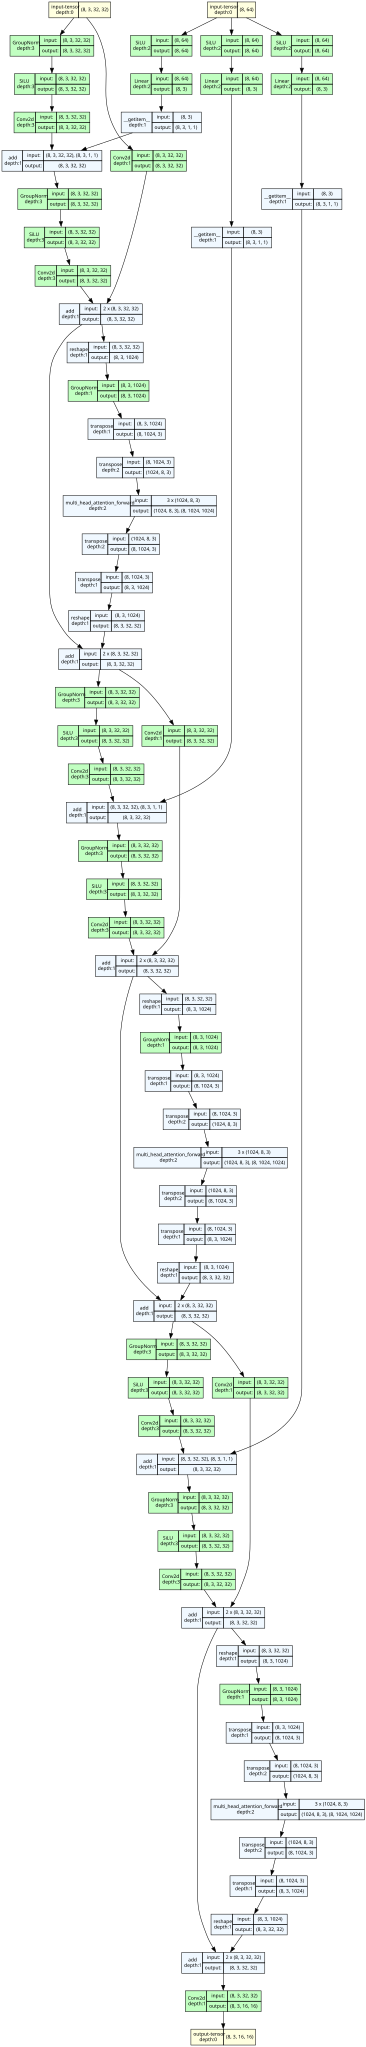

In [5]:

class Resnet(nn.Module):
    def __init__(
        self, num_groups, in_channels, out_channels, *args: Any, **kwargs: Any
    ) -> None:
        super().__init__(*args, **kwargs)
        self.net = nn.Sequential(
            nn.GroupNorm(num_groups, in_channels),
            nn.SiLU(),
            nn.Conv2d(in_channels, out_channels, kernel_size=3, stride=1, padding=1),
        )

    def forward(self, x):
        return self.net(x)


class DownBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        t_emb_dim: int,
        down_sample: bool,
        num_heads: int,
        num_layers: int,
        attn: bool,
        norm_channels: int,
        *args: Any,
        **kwargs: Any,
    ) -> None:
        super().__init__(*args, **kwargs)

        self.num_layers = num_layers
        self.t_emb_dim = t_emb_dim
        self.num_heads = num_heads
        self.attn = attn
        self.down_sample = down_sample

        self.resnet_conv_first = nn.ModuleList(
            [
                Resnet(
                    norm_channels,
                    in_channels=in_channels if i == 0 else out_channels,
                    out_channels=out_channels,
                )
                for i in range(num_layers)
            ]
        )
        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList(
                [
                    nn.Sequential(nn.SiLU(), nn.Linear(self.t_emb_dim, out_channels))
                    for _ in range(num_layers)
                ]
            )

        self.resnet_conv_second = nn.ModuleList(
            [
                Resnet(norm_channels, out_channels, out_channels)
                for i in range(num_layers)
            ]
        )

        if self.attn:
            self.attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels) for x in range(num_layers)]
            )
            self.attentions = nn.ModuleList(
                [
                    nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                    for x in range(num_layers)
                ]
            )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels if x == 0 else out_channels, out_channels, kernel_size=1
                )
                for x in range(num_layers)
            ]
        )

        self.down_sample_conv = (
            nn.Conv2d(out_channels, out_channels, kernel_size=4, stride=2, padding=1)
            if self.down_sample
            else nn.Identity()
        )

    def forward(self, x: Tensor, t_emb=None):
        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            if self.attn:
                # Attention Block
                batch_size, channels, h, w = out.shape
                in_attn: Tensor = out.reshape(batch_size, channels, h * w)
                in_attn = self.attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
                # print(type(out_attn), type(ssss))
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn
        return self.down_sample_conv(out)

torchview.draw_graph(
    DownBlock(
        in_channels = 3, 
        out_channels = 3, 
        t_emb_dim=64, 
        down_sample = True, 
        num_heads = 3, 
        num_layers = 3, 
        attn = True, 
        norm_channels = 1,
    ), 
    input_data =[ torch.rand((8,3,32,32)), torch.rand(8, 64)],
    
).visual_graph

In [43]:

class MidBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        t_emb_dim: int,
        num_heads: int,
        num_layers: int,
        norm_channels: int,
        attn: bool = True,
        cross_attn: bool = False,
        context_dim: int = None, 
        *args: Any,
        **kwargs: Any,
    ) -> None:
        super().__init__(*args, **kwargs)

        self.num_layers = num_layers
        self.t_emb_dim = t_emb_dim
        self.num_heads = num_heads
        self.attn = attn

        self.resnet_conv_first = nn.ModuleList(
            [
                Resnet(
                    norm_channels,
                    in_channels=in_channels if i == 0 else out_channels,
                    out_channels=out_channels,
                )
                for i in range(num_layers + 1)
            ]
        )
        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList(
                [
                    nn.Sequential(nn.SiLU(), nn.Linear(self.t_emb_dim, out_channels))
                    for _ in range(num_layers + 1)
                ]
            )

        self.resnet_conv_second = nn.ModuleList(
            [
                Resnet(norm_channels, out_channels, out_channels)
                for i in range(num_layers + 1)
            ]
        )

        if self.attn:
            self.attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels) for x in range(num_layers)]
            )
            self.attentions = nn.ModuleList(
                [
                    nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                    for x in range(num_layers)
                ]
            )
            
        if self.cross_attn:
            assert context_dim is not None, "Context Dimension must be passed for cross attention"
            self.cross_attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )
            self.cross_attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )
            self.context_proj = nn.ModuleList(
                [nn.Linear(context_dim, out_channels)
                 for _ in range(num_layers)]
            )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels if x == 0 else out_channels, out_channels, kernel_size=1
                )
                for x in range(num_layers + 1)
            ]
        )

    def forward(self, x, t_emb=None,  context=None):
        out = x
        resnet_input = out
        out = self.resnet_conv_first[0](out)
        if self.t_emb_dim is not None:
            out = out + self.t_emb_layers[0](t_emb)[:, :, None, None]
        out = self.resnet_conv_second[0](out)
        out = out + self.residual_input_conv[0](resnet_input)

        for i in range(self.num_layers):
            batch_size, channels, h, w = out.shape
            in_attn: Tensor = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            # print(type(out_attn), type(ssss))
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            
            
            if self.cross_attn:
                assert context is not None, "context cannot be None if cross attention layers are used"
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.cross_attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                assert context.shape[0] == x.shape[0] and context.shape[-1] == self.context_dim
                context_proj = self.context_proj[i](context)
                out_attn, _ = self.cross_attentions[i](in_attn, context_proj, context_proj)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn

            # following resnet blocks
            resnet_input = out
            out = self.resnet_conv_first[i + 1](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i + 1](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i + 1](out)
            out = out + self.residual_input_conv[i + 1](resnet_input)

        return out
    
# torchview.draw_graph(
#     MidBlock(
#         in_channels = 3, 
#         out_channels = 3, 
#         t_emb_dim=64, 
#         num_heads = 3, 
#         num_layers = 3, 
#         attn = True, 
#         norm_channels = 1,
#     ), 
#     input_data =[ torch.rand((8,3,32,32)), torch.rand(8, 64)],
    
# ).visual_graph

In [34]:

class UpBlock(nn.Module):
    def __init__(
        self,
        in_channels: int,
        out_channels: int,
        up_sample: bool,
        num_heads: int,
        num_layers: int,
        attn: bool,
        norm_channels: int,
        t_emb_dim: int = None,
        *args: Any,
        **kwargs: Any,
    ) -> None:
        super().__init__(*args, **kwargs)

        self.num_layers = num_layers
        self.t_emb_dim = t_emb_dim
        self.num_heads = num_heads
        self.attn = attn
        self.up_sample = up_sample

        self.resnet_conv_first = nn.ModuleList(
            [
                Resnet(
                    norm_channels,
                    in_channels=in_channels if i == 0 else out_channels,
                    out_channels=out_channels,
                )
                for i in range(num_layers)
            ]
        )
        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList(
                [
                    nn.Sequential(nn.SiLU(), nn.Linear(self.t_emb_dim, out_channels))
                    for _ in range(num_layers)
                ]
            )

        self.resnet_conv_second = nn.ModuleList(
            [
                Resnet(norm_channels, out_channels, out_channels)
                for i in range(num_layers)
            ]
        )

        if self.attn:
            self.attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels) for x in range(num_layers)]
            )
            self.attentions = nn.ModuleList(
                [
                    nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                    for x in range(num_layers)
                ]
            )

        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(
                    in_channels if x == 0 else out_channels, out_channels, kernel_size=1
                )
                for x in range(num_layers)
            ]
        )

        self.up_sample_conv = (
            nn.ConvTranspose2d(
                in_channels, in_channels, kernel_size=4, stride=2, padding=1
            )
            if self.up_sample
            else nn.Identity()
        )

    def forward(self, x, out_down=None, t_emb=None):
        x = self.up_sample_conv(x)
        if out_down is not None:
            x = torch.cat([x, out_down], dim=1)
        out = x
        for i in range(self.num_layers):
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)

            if self.attn:
                # Attention Block
                batch_size, channels, h, w = out.shape
                in_attn: Tensor = out.reshape(batch_size, channels, h * w)
                in_attn = self.attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
                # print(type(out_attn), type(ssss))
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn
        return out
    
    
    

class UpBlockUnet(nn.Module):
    r"""
    Up conv block with attention.
    Sequence of following blocks
    1. Upsample
    1. Concatenate Down block output
    2. Resnet block with time embedding
    3. Attention Block
    """
    
    def __init__(self, in_channels, out_channels, t_emb_dim, up_sample,
                 num_heads, num_layers, norm_channels, cross_attn=False, context_dim=None):
        super().__init__()
        self.num_layers = num_layers
        self.up_sample = up_sample
        self.t_emb_dim = t_emb_dim
        self.cross_attn = cross_attn
        self.context_dim = context_dim
        self.resnet_conv_first = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, in_channels if i == 0 else out_channels),
                    nn.SiLU(),
                    nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=3, stride=1,
                              padding=1),
                )
                for i in range(num_layers)
            ]
        )
        
        if self.t_emb_dim is not None:
            self.t_emb_layers = nn.ModuleList([
                nn.Sequential(
                    nn.SiLU(),
                    nn.Linear(t_emb_dim, out_channels)
                )
                for _ in range(num_layers)
            ])
            
        self.resnet_conv_second = nn.ModuleList(
            [
                nn.Sequential(
                    nn.GroupNorm(norm_channels, out_channels),
                    nn.SiLU(),
                    nn.Conv2d(out_channels, out_channels, kernel_size=3, stride=1, padding=1),
                )
                for _ in range(num_layers)
            ]
        )
        
        self.attention_norms = nn.ModuleList(
            [
                nn.GroupNorm(norm_channels, out_channels)
                for _ in range(num_layers)
            ]
        )
        
        self.attentions = nn.ModuleList(
            [
                nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                for _ in range(num_layers)
            ]
        )
        
        if self.cross_attn:
            assert context_dim is not None, "Context Dimension must be passed for cross attention"
            self.cross_attention_norms = nn.ModuleList(
                [nn.GroupNorm(norm_channels, out_channels)
                 for _ in range(num_layers)]
            )
            self.cross_attentions = nn.ModuleList(
                [nn.MultiheadAttention(out_channels, num_heads, batch_first=True)
                 for _ in range(num_layers)]
            )
            self.context_proj = nn.ModuleList(
                [nn.Linear(context_dim, out_channels)
                 for _ in range(num_layers)]
            )
        self.residual_input_conv = nn.ModuleList(
            [
                nn.Conv2d(in_channels if i == 0 else out_channels, out_channels, kernel_size=1)
                for i in range(num_layers)
            ]
        )
        self.up_sample_conv = nn.ConvTranspose2d(in_channels // 2, in_channels // 2,
                                                 4, 2, 1) \
            if self.up_sample else nn.Identity()
    
    def forward(self, x, out_down=None, t_emb=None, context=None):
        x = self.up_sample_conv(x)
        if out_down is not None:
            x = torch.cat([x, out_down], dim=1)
        
        out = x
        for i in range(self.num_layers):
            # Resnet
            resnet_input = out
            out = self.resnet_conv_first[i](out)
            if self.t_emb_dim is not None:
                out = out + self.t_emb_layers[i](t_emb)[:, :, None, None]
            out = self.resnet_conv_second[i](out)
            out = out + self.residual_input_conv[i](resnet_input)
            # Self Attention
            batch_size, channels, h, w = out.shape
            in_attn = out.reshape(batch_size, channels, h * w)
            in_attn = self.attention_norms[i](in_attn)
            in_attn = in_attn.transpose(1, 2)
            out_attn, _ = self.attentions[i](in_attn, in_attn, in_attn)
            out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
            out = out + out_attn
            # Cross Attention
            if self.cross_attn:
                assert context is not None, "context cannot be None if cross attention layers are used"
                batch_size, channels, h, w = out.shape
                in_attn = out.reshape(batch_size, channels, h * w)
                in_attn = self.cross_attention_norms[i](in_attn)
                in_attn = in_attn.transpose(1, 2)
                assert len(context.shape) == 3, \
                    "Context shape does not match B,_,CONTEXT_DIM"
                assert context.shape[0] == x.shape[0] and context.shape[-1] == self.context_dim,\
                    "Context shape does not match B,_,CONTEXT_DIM"
                context_proj = self.context_proj[i](context)
                out_attn, _ = self.cross_attentions[i](in_attn, context_proj, context_proj)
                out_attn = out_attn.transpose(1, 2).reshape(batch_size, channels, h, w)
                out = out + out_attn
        
        return out

In [8]:
class VQVAE(nn.Module):
    def __init__(self, im_channels=3, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)
        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.down_sample = [True, True, True]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32

        # To disable attention in DownBlock of Encoder and Upblock of Decoder
        self.attns = [False, False, False]
        self.num_heads = 4

        # Latent Dimensions
        self.z_channels = 3
        self.codebook_size = 8192

        # Wherever we use downsampling in encoder correspondingly use
        # upsampling in decoder
        self.up_sample = list(reversed(self.down_sample))

        ######## Encoder ##########
        self.encoder_conv_in = nn.Conv2d(
            im_channels, self.down_channels[0], kernel_size=3, padding=(1, 1)
        )

        self.encoder_downs = nn.ModuleList([])
        for i in range(len(self.down_channels) - 1):
            self.encoder_downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    t_emb_dim=None,
                    norm_channels=self.norm_channels,
                    down_sample=self.down_sample[i],
                )
            )

        self.encoder_mids = nn.ModuleList([])
        for i in range(len(self.mid_channels) - 1):
            self.encoder_mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    t_emb_dim=None,
                    num_heads=self.num_heads,
                    num_layers=self.num_mid_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.encoder_norm_out = nn.GroupNorm(self.norm_channels, self.down_channels[-1])
        self.encoder_conv_out = nn.Conv2d(
            self.down_channels[-1], self.z_channels, kernel_size=3, padding=1
        )

        self.pre_quant_conv = nn.Conv2d(self.z_channels, self.z_channels, kernel_size=1)
        self.embedding = nn.Embedding(self.codebook_size, self.z_channels)

        ######## Decoder ########
        self.post_quant_conv = nn.Conv2d(
            self.z_channels, self.z_channels, kernel_size=1
        )
        # IMPORTANT: Fix decoder_conv_in to match the expected input channels.
        # Before:
        # self.decoder_conv_in = nn.Conv2d(
        #     self.z_channels, self.mid_channels[-1], kernel_size=1, padding=(1, 1)
        # )
        # After: Should map z_channels -> mid_channels[0] not mid_channels[-1]!
        self.decoder_conv_in = nn.Conv2d(
            self.z_channels, self.mid_channels[0], kernel_size=3, padding=1
        )

        self.decoder_mids = nn.ModuleList()
        for i in reversed(range(1, len(self.mid_channels))):
            self.decoder_mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i - 1],
                    t_emb_dim=None,
                    num_heads=self.num_heads,
                    num_layers=self.num_mid_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.decoder_ups = nn.ModuleList()
        for i in reversed(range(1, len(self.down_channels))):
            self.decoder_ups.append(
                UpBlock(
                    self.down_channels[i],
                    self.down_channels[i - 1],
                    num_heads=self.num_heads,
                    num_layers=self.num_up_layers,
                    attn=self.attns[i - 1],
                    norm_channels=self.norm_channels,
                    up_sample=self.up_sample[i - 1],
                )
            )

        self.decoder_norm_out = nn.GroupNorm(
            self.norm_channels, self.down_channels[0]
        )
        self.decoder_conv_out = nn.Conv2d(
            self.down_channels[0],
            im_channels,
            kernel_size=3,
            padding=1,
        )

    def quantize(self, x):
        B, C, H, W = x.shape

        # B, C, H, W -> B, H, W, C
        x = x.permute(0, 2, 3, 1)

        # B, H, W, C -> B, H * W, C
        x = x.reshape(B, H * W, C)
        dist = torch.cdist(x, self.embedding.weight[None, :].repeat((B, 1, 1)))

        min_encoding_indices = torch.argmin(dist, dim=-1)

        quant_out = torch.index_select(
            self.embedding.weight, 0, min_encoding_indices.view(-1)
        )

        x_ = x.reshape((-1, x.size(-1)))
        commitment_loss = torch.mean((quant_out.detach() - x_) ** 2)
        codebook_loss = torch.mean((quant_out - x_.detach()) ** 2)

        quantize_losses = {
            "codebook_loss": codebook_loss,
            "commitment_loss": commitment_loss
        }

        quant_out = x_ + (quant_out - x_).detach()
        quant_out = quant_out.reshape(B, H, W, C).permute(0, 3, 1, 2)

        return quant_out, quantize_losses

    def encode(self, x):
        x = self.encoder_conv_in(x)
        for down in self.encoder_downs:
            x = down(x)
        for mid in self.encoder_mids:
            x = mid(x)

        x = self.encoder_norm_out(x)
        x = nn.SiLU()(x)
        x = self.encoder_conv_out(x)
        x = self.pre_quant_conv(x)
        x, quant_losses = self.quantize(x)
        return x, quant_losses

    def decode(self, x):
        x = self.post_quant_conv(x)
        x = self.decoder_conv_in(x)
        for mid in self.decoder_mids:
            x = mid(x)
        for up in self.decoder_ups:
            x = up(x)

        x = self.decoder_norm_out(x)
        x = nn.SiLU()(x)
        x = self.decoder_conv_out(x)
        return x

    def forward(self, x: Tensor):
        z, quant_losses = self.encode(x)
        x = self.decode(z)
        return x, z, quant_losses


# VQVAE(3).forward(torch.rand((8, 3, 32, 32)))

# Training

In [31]:
from tqdm import tqdm

import pickle
import glob
import os
import torch
from torch import nn
from typing import Any
import torch
from torch import Tensor
class Discriminator(nn.Module):
    def __init__(
        self,
        im_channels=3,
        conv_channels=[64, 128, 256],
        kernels=[4, 4, 4, 4],
        strides=[2, 2, 2, 2],
        paddings=[1, 1, 1, 1],
        *args: Any,
        **kwargs: Any,
    ) -> None:
        super().__init__(*args, **kwargs)

        self.im_channels = im_channels
        self.conv_channels = conv_channels
        self.kernels = kernels
        self.strides = strides
        self.paddings = paddings

        activation = nn.LeakyReLU(0.2)
        layers_dim = [self.im_channels] + conv_channels + [1]
        self.layers = nn.ModuleList(
            [
                nn.Sequential(
                    nn.Conv2d(
                        in_channels=layers_dim[i],
                        out_channels=layers_dim[i + 1],
                        kernel_size=kernels[i],
                        stride=strides[i],
                        padding=paddings[i],
                    ),
                    nn.BatchNorm2d(layers_dim[i + 1])
                    if i != len(layers_dim) - 2 and i != 0
                    else nn.Identity(),
                    activation if i != len(layers_dim) - 2 else nn.Identity(),
                )
                for i in range(len(layers_dim) - 1)
            ]
        )

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        return x


def load_latents(latent_path):
    r"""
    Simple utility to save latents to speed up ldm training
    :param latent_path:
    :return:
    """
    latent_maps = {}
    for fname in glob.glob(os.path.join(latent_path, "*.pkl")):
        s = pickle.load(open(fname, "rb"))
        for k, v in s.items():
            latent_maps[k] = v[0]
    return latent_maps


def drop_text_condition(text_embed, im, empty_text_embed, text_drop_prob):
    if text_drop_prob > 0:
        text_drop_mask = (
            torch.zeros((im.shape[0]), device=im.device).float().uniform_(0, 1)
            < text_drop_prob
        )
        assert empty_text_embed is not None, (
            "Text Conditioning required as well as"
            " text dropping but empty text representation not created"
        )
        text_embed[text_drop_mask, :, :] = empty_text_embed[0]
    return text_embed


def drop_image_condition(image_condition, im, im_drop_prob):
    if im_drop_prob > 0:
        im_drop_mask = (
            torch.zeros((im.shape[0], 1, 1, 1), device=im.device).float().uniform_(0, 1)
            > im_drop_prob
        )
        return image_condition * im_drop_mask
    else:
        return image_condition


def drop_class_condition(class_condition, class_drop_prob, im):
    if class_drop_prob > 0:
        class_drop_mask = (
            torch.zeros((im.shape[0], 1), device=im.device).float().uniform_(0, 1)
            > class_drop_prob
        )
        return class_condition * class_drop_mask
    else:
        return class_condition



In [ ]:
import lpips
import matplotlib.pyplot as plt
import torchvision

loss_fn_alex = lpips.LPIPS(net="alex")  # best forward scores
loss_fn_vgg = lpips.LPIPS(
    net="vgg"
)  # closer to "traditional" perceptual loss, when used for optimization

import torch

img0 = torch.rand(1, 3, 64, 64)  # image should be RGB, IMPORTANT: normalized to [-1,1]
img1 = torch.rand(1, 3, 64, 64)
d = loss_fn_alex(img0, img1)

# plt.imshow(
#     torchvision.utils.make_grid(torch.cat([img0, img1])).permute(1, 2, 0).numpy()
# )
# plt.axis("off")
# print("D value: ", d)
# plt.show()

Setting up [LPIPS] perceptual loss: trunk [alex], v[0.1], spatial [off]


/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=AlexNet_Weights.IMAGENET1K_V1`. You can also use `weights=AlexNet_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/alex.pth
Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Loading model from: /Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv/lib/python3.13/site-packages/lpips/weights/v0.1/vgg.pth


Adversarial Loss - an idea from GAN networks which is used to compare the fake and real images set --- so in practive this will help the generator to fake generation which is very similar to the real image almost indistingushable. Because L1/L2 reconstruction loss and perceptual loss may fail to identify small differences but adversarial loss helps to find them.

In [ ]:


def drop_text_condition(text_embed, im, empty_text_embed, text_drop_prob):
    if text_drop_prob > 0:
        text_drop_mask = (
            torch.zeros((im.shape[0]), device=im.device).float().uniform_(0, 1)
            < text_drop_prob
        )
        assert empty_text_embed is not None, (
            "Text Conditioning required as well as"
            " text dropping but empty text representation not created"
        )
        text_embed[text_drop_mask, :, :] = empty_text_embed[0]
    return text_embed


def drop_image_condition(image_condition, im, im_drop_prob):
    if im_drop_prob > 0:
        im_drop_mask = (
            torch.zeros((im.shape[0], 1, 1, 1), device=im.device).float().uniform_(0, 1)
            > im_drop_prob
        )
        return image_condition * im_drop_mask
    else:
        return image_condition


def drop_class_condition(class_condition, class_drop_prob, im):
    if class_drop_prob > 0:
        class_drop_mask = (
            torch.zeros((im.shape[0], 1), device=im.device).float().uniform_(0, 1)
            > class_drop_prob
        )
        return class_condition * class_drop_mask
    else:
        return class_condition


In [42]:
import glob
import os
import torchvision
from PIL import Image
from tqdm import tqdm
from torch.utils.data.dataset import Dataset

class MnistDataset(Dataset):
    r"""
    Nothing special here. Just a simple dataset class for mnist images.
    Created a dataset class rather using torchvision to allow
    replacement with any other image dataset
    """

    def __init__(
        self,
        split,
        im_path,
        im_size,
        im_channels,
        use_latents=False,
        latent_path=None,
        condition_config=None,
    ):
        r"""
        Init method for initializing the dataset properties
        :param split: train/test to locate the image files
        :param im_path: root folder of images
        :param im_ext: image extension. assumes all
        images would be this type.
        """
        self.split = split
        self.im_size = im_size
        self.im_channels = im_channels

        # Should we use latents or not
        self.latent_maps = None
        self.use_latents = False

        # Conditioning for the dataset
        self.condition_types = (
            [] if condition_config is None else condition_config["condition_types"]
        )

        self.images, self.labels = self.load_images(im_path)

        # Whether to load images and call vae or to load latents
        if use_latents and latent_path is not None:
            latent_maps = load_latents(latent_path)
            if len(latent_maps) == len(self.images):
                self.use_latents = True
                self.latent_maps = latent_maps
                print("Found {} latents".format(len(self.latent_maps)))
            else:
                print("Latents not found")

    def load_images(self, im_path):
        r"""
        Gets all images from the path specified
        and stacks them all up
        :param im_path:
        :return:
        """
        assert os.path.exists(im_path), "images path {} does not exist".format(im_path)
        ims = []
        labels = []
        for d_name in tqdm(os.listdir(im_path)):
            fnames = glob.glob(os.path.join(im_path, d_name, "*.{}".format("png")))
            fnames += glob.glob(os.path.join(im_path, d_name, "*.{}".format("jpg")))
            fnames += glob.glob(os.path.join(im_path, d_name, "*.{}".format("jpeg")))
            for fname in fnames:
                ims.append(fname)
                if "class" in self.condition_types:
                    labels.append(int(d_name))
        print("Found {} images for split {}".format(len(ims), self.split))
        return ims, labels

    def __len__(self):
        return len(self.images)

    def __getitem__(self, index):
        ######## Set Conditioning Info ########
        cond_inputs = {}
        if "class" in self.condition_types:
            cond_inputs["class"] = self.labels[index]
        #######################################

        if self.use_latents:
            latent = self.latent_maps[self.images[index]]
            if len(self.condition_types) == 0:
                return latent
            else:
                return latent, cond_inputs
        else:
            im = Image.open(self.images[index])
            im = im.convert("L" if self.im_channels == 1 else "RGB")
            im = im.resize((self.im_size, self.im_size))    
            im_tensor = torchvision.transforms.ToTensor()(im)

            # Convert input to -1 to 1 range.
            im_tensor = (2 * im_tensor) - 1
            if len(self.condition_types) == 0:
                return im_tensor
            else:
                return im_tensor, cond_inputs



In [45]:

import torchvision
import os

from torchvision.transforms import ToTensor

mn = torchvision.datasets.MNIST("mnist", download=True, transform=ToTensor())
labels = mn.train_labels
data = mn.train_data
for idx, label in enumerate(mn.train_labels):
    img = data[idx]
    if not os.path.exists(f"mnist/{label}"):
        os.mkdir(f"mnist/{label}")

    fpath = f"mnist/{label}/{idx}.png"
    if not os.path.exists(fpath):
        torchvision.utils.save_image(img.float() / 255.0, fpath)


dataset = MnistDataset(split="train", im_path="mnist", im_size=32, im_channels=1)
loader = torch.utils.data.DataLoader(dataset, batch_size=64, shuffle=True)



100%|██████████| 11/11 [00:00<00:00, 129.82it/s]

Found 60000 images for split train


In [46]:
import yaml
import argparse
import torch
import random
import torchvision
import os
import numpy as np
from tqdm import tqdm
from torch.optim import Adam
from torchvision.utils import make_grid

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")


# Set the desired seed value #
seed = 42
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)
if device == "cuda":
    torch.cuda.manual_seed_all(seed)
#############################

# Create the model and dataset #
model = VQVAE(im_channels=1).to(device)

device = "cuda" if torch.cuda.is_available() else "cpu"
lpips_model = loss_fn_vgg.to(device)

EPOCHS = 10
IMAGE_CHANNELS = 1
AUTOENCODER_LR = 2e-4
commitment_beta = 0.2
codebook_weight = 1
disc_weight = 0.5
perceptual_weight = 1
vqvae_autoencoder_ckpt_name = "vqvae"
task_name = "vqvae_train"
vqvae_discriminator_ckpt_name = "vqvae_discriminator"

# L1/L2 loss for Reconstruction
recon_criterion = torch.nn.MSELoss()
# Disc Loss can even be BCEWithLogits
disc_criterion = torch.nn.MSELoss()

# No need to freeze lpips as lpips.py takes care of that
discriminator = Discriminator(im_channels=1).to(device)

optimizer_d = Adam(discriminator.parameters(), lr=AUTOENCODER_LR, betas=(0.5, 0.999))
optimizer_g = Adam(model.parameters(), lr=AUTOENCODER_LR, betas=(0.5, 0.999))

disc_step_start = 2000
step_count = 0

# This is for accumulating gradients incase the images are huge
# And one cant afford higher batch sizes
acc_steps = 2
image_save_steps = 100
img_save_count = 0

os.makedirs(task_name, exist_ok=True)

for epoch_idx in range(EPOCHS):
    recon_losses = []
    codebook_losses = []
    # commitment_losses = []
    perceptual_losses = []
    disc_losses = []
    gen_losses = []
    losses = []

    optimizer_g.zero_grad()
    optimizer_d.zero_grad()

    for im in tqdm(loader):
        step_count += 1
        im = im.float().to(device)

        # Fetch autoencoders output(reconstructions)
        model_output = model(im)
        output, z, quantize_losses = model_output

        # Image Saving Logic
        if step_count % image_save_steps == 0 or step_count == 1:
            sample_size = min(8, im.shape[0])
            save_output = torch.clamp(output[:sample_size], -1.0, 1.0).detach().cpu()
            save_output = (save_output + 1) / 2
            save_input = ((im[:sample_size] + 1) / 2).detach().cpu()

            grid = make_grid(
                torch.cat([save_input, save_output], dim=0), nrow=sample_size
            )
            img = torchvision.transforms.ToPILImage()(grid)
            if not os.path.exists("vqvae_samples"):
                os.mkdir("vqvae_samples")
            img.save(
                os.path.join(
                    "vqvae_samples",
                    "current_autoencoder_sample_{}.png".format(img_save_count),
                )
            )
            img_save_count += 1
            img.close()

        ######### Optimize Generator ##########
        # L2 Loss
        recon_loss = recon_criterion(output, im)
        recon_losses.append(recon_loss.item())
        recon_loss = recon_loss / acc_steps
        g_loss = (
            recon_loss
            + (codebook_weight * quantize_losses["codebook_loss"] / acc_steps)
            + (commitment_beta * quantize_losses["commitment_loss"] / acc_steps)
        )
        codebook_losses.append(
            codebook_weight * quantize_losses["codebook_loss"].item()
        )
        # Adversarial loss only if disc_step_start steps passed
        if step_count > disc_step_start:
            disc_fake_pred = discriminator(model_output[0])
            disc_fake_loss = disc_criterion(
                disc_fake_pred,
                torch.ones(disc_fake_pred.shape, device=disc_fake_pred.device),
            )
            gen_losses.append(disc_weight * disc_fake_loss.item())
            g_loss += disc_weight * disc_fake_loss / acc_steps
        lpips_loss = torch.mean(lpips_model(output, im))
        perceptual_losses.append(perceptual_weight * lpips_loss.item())
        g_loss += perceptual_weight * lpips_loss / acc_steps
        losses.append(g_loss.item())
        g_loss.backward()
        #####################################

        ######### Optimize Discriminator #######
        if step_count > disc_step_start:
            fake = output
            disc_fake_pred = discriminator(fake.detach())
            disc_real_pred = discriminator(im)
            disc_fake_loss = disc_criterion(
                disc_fake_pred,
                torch.zeros(disc_fake_pred.shape, device=disc_fake_pred.device),
            )
            disc_real_loss = disc_criterion(
                disc_real_pred,
                torch.ones(disc_real_pred.shape, device=disc_real_pred.device),
            )
            disc_loss = disc_weight * (disc_fake_loss + disc_real_loss) / 2
            disc_losses.append(disc_loss.item())
            disc_loss = disc_loss / acc_steps
            disc_loss.backward()
            if step_count % acc_steps == 0:
                optimizer_d.step()
                optimizer_d.zero_grad()
        #####################################

        if step_count % acc_steps == 0:
            optimizer_g.step()
            optimizer_g.zero_grad()
    optimizer_d.step()
    optimizer_d.zero_grad()
    optimizer_g.step()
    optimizer_g.zero_grad()
    if len(disc_losses) > 0:
        print(
            "Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | "
            "Codebook : {:.4f} | G Loss : {:.4f} | D Loss {:.4f}".format(
                epoch_idx + 1,
                np.mean(recon_losses),
                np.mean(perceptual_losses),
                np.mean(codebook_losses),
                np.mean(gen_losses),
                np.mean(disc_losses),
            )
        )
    else:
        print(
            "Finished epoch: {} | Recon Loss : {:.4f} | Perceptual Loss : {:.4f} | Codebook : {:.4f}".format(
                epoch_idx + 1,
                np.mean(recon_losses),
                np.mean(perceptual_losses),
                np.mean(codebook_losses),
            )
        )

    torch.save(model.state_dict(), os.path.join(task_name, vqvae_autoencoder_ckpt_name))
    torch.save(
        discriminator.state_dict(),
        os.path.join(task_name, vqvae_discriminator_ckpt_name),
    )
print("Done Training...")



100%|██████████| 938/938 [01:15<00:00, 12.37it/s]


Finished epoch: 1 | Recon Loss : 0.2133 | Perceptual Loss : 0.2058 | Codebook : 0.0048


100%|██████████| 938/938 [01:15<00:00, 12.35it/s]


Finished epoch: 2 | Recon Loss : 0.0640 | Perceptual Loss : 0.0764 | Codebook : 0.0063


100%|██████████| 938/938 [01:22<00:00, 11.37it/s]


...

Finished epoch: 8 | Recon Loss : 0.0312 | Perceptual Loss : 0.0397 | Codebook : 0.0070 | G Loss : 0.0329 | D Loss 0.1556


100%|██████████| 938/938 [01:23<00:00, 11.23it/s]


Finished epoch: 9 | Recon Loss : 0.0294 | Perceptual Loss : 0.0374 | Codebook : 0.0070 | G Loss : 0.0328 | D Loss 0.1555


100%|██████████| 938/938 [01:23<00:00, 11.25it/s]


Finished epoch: 10 | Recon Loss : 0.0279 | Perceptual Loss : 0.0354 | Codebook : 0.0070 | G Loss : 0.0328 | D Loss 0.1553
Done Training...


In [ ]:
# !uv pip install torchinfo


Using Python 3.13.2 environment at: /Users/aslonkhamidov/Desktop/code/learning/deep_learning_mit/.venv
Resolved 1 package in 823ms                                          
⠙ Preparing packages... (0/1)                                                   
⠙ Preparing packages... (0/1)----     0 B/22.83 KiB                     
⠙ Preparing packages... (0/1)---- 14.84 KiB/22.83 KiB                   
Prepared 1 package in 126ms                                                  
Installed 1 package in 2ms                                  
 + torchinfo==1.8.0


In [48]:
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params / 10 ** 6, trainable_params / 10 ** 6

(21.979356, 21.979356)

/tmp/ipykernel_1184130/3589232711.py:10: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load("vqvae_train/vqvae", map_location=device))


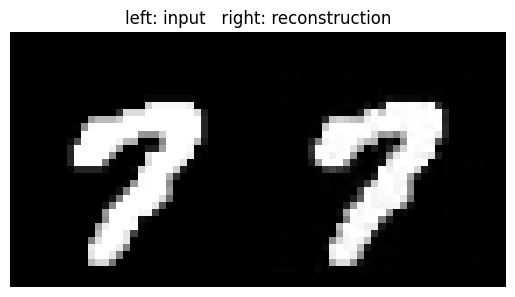

In [50]:
import torch
import torchvision
import matplotlib.pyplot as plt
from PIL import Image

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ---- Load the trained model ----
model = VQVAE(im_channels=1).to(device)
model.load_state_dict(torch.load("vqvae_train/vqvae", map_location=device))
model.eval()

# ---- Preprocess an image exactly like training ----
def load_image(path, im_size=32):
    im = Image.open(path).convert("L").resize((im_size, im_size))
    t = torchvision.transforms.ToTensor()(im)   # [0,1], shape [1,H,W]
    t = 2 * t - 1                                # -> [-1,1]
    return t.unsqueeze(0)                        # add batch dim -> [1,1,H,W]

x = load_image("mnist/7/15.png").to(device)

# ---- Run inference ----
with torch.no_grad():
    recon, z, quant_losses = model(x)           # full encode->quantize->decode
    # or step-by-step:
    # z, quant_losses = model.encode(x)          # quantized latent [B,3,4,4]
    # recon = model.decode(z)

# ---- Back to viewable [0,1] ----
def to_img(t):
    return ((t.clamp(-1, 1) + 1) / 2).cpu()

inp  = to_img(x)
out  = to_img(recon)

# ---- Show input vs reconstruction ----
grid = torchvision.utils.make_grid(torch.cat([inp, out], dim=0), nrow=2)
plt.imshow(grid.permute(1, 2, 0).numpy(), cmap="gray")
plt.axis("off")
plt.title("left: input   right: reconstruction")
plt.show()

### Add Conditioning to DDPM model

In [ ]:
from torch import einsum


def get_time_embedding(t: Tensor, t_emb_dim):
    factor = 10000 ** (
        (
            torch.arange(
                start=0, end=t_emb_dim // 2, dtype=torch.float32, device=t.device
            )
        )
        / (t_emb_dim // 2)
    )

    t_emb = t[:, None].repeat(1, t_emb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1)

    return t_emb


class UNetBase(nn.Module):
    def __init__(self, im_channels: int, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.t_emb_dim = 256
        self.down_sample = [True, True, True]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32
        self.attns = [True, True, True]
        self.num_heads = 16
        self.conv_out_channels = 1

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
        )

        self.conv_in = nn.Conv2d(
            im_channels, self.down_channels[0], kernel_size=3, padding=1
        )
        self.downs = nn.ModuleList()
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels,
                )
            )

        self.mids = nn.ModuleList()
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.ups = nn.ModuleList()
        for i in reversed(range(len(self.down_channels) - 1)):
            # print(
            #     "In Channels", self.down_channels[i] * 2
            # )
            # print("Out Channels", self.down_channels[i - 1] if i != 0 else self.down_channels[0])
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else self.down_channels[0],
                    up_sample=self.down_sample[i],
                    t_emb_dim=self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.down_channels[0],  # was self.conv_out_channels
        )
        self.conv_out = nn.Conv2d(
            self.down_channels[0],
            self.conv_out_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x: Tensor, t):
        # shapes assuiming dowblocks - [c1, c2, c3,c4 ...]
        # shapes midblocks - [c4, c4, c3]
        # up samples - [c3, c2, c1]
        # B X C X H X W
        out = self.conv_in(x)
        # B X C1 X H X W
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        self.up_outs = []
        for idx, up in enumerate(self.ups):
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)

        return out


class UnetCond(nn.Module):
    def __init__(self, im_channels: int = 3, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        super().__init__(*args, **kwargs)

        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.t_emb_dim = 256
        self.down_sample = [True, True, True]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32
        self.attns = [True, True, True]
        self.num_heads = 16
        self.conv_out_channels = 1

        ######## Class, Mask and Text Conditioning Config #####
        self.class_cond = False
        self.text_cond = False
        self.image_cond = False
        self.text_embed_dim = None
        self.condition_config = {
            "condition_types": ["class"],
            "class_condition_config": {
                "num_classes": 10,
            },
            "text_condition_config": {
                "text_embed_dim": 256,
            },
            "image_condition_config": {
                "image_condition_input_channels": 1,
                "image_condition_output_channels": 1,
            },
        }
        condition_types = self.condition_config["condition_types"]  # ["class", "text", "image"]
        if self.condition_config is not None:
            assert "condition_types" in self.condition_config, (
                "Condition Type not provided in model config"
            )
            if "class" in condition_types:
                # validate_class_config(self.condition_config)
                self.class_cond = True
                self.num_classes = self.condition_config["class_condition_config"][
                    "num_classes"
                ]
            if "text" in condition_types:
                self.text_cond = True
                self.text_embed_dim = self.condition_config["text_condition_config"][
                    "text_embed_dim"
                ]
            if "image" in condition_types:
                self.image_cond = True
                self.im_cond_input_ch = self.condition_config["image_condition_config"][
                    "image_condition_input_channels"
                ]
                self.im_cond_output_ch = self.condition_config[
                    "image_condition_config"
                ]["image_condition_output_channels"]
        if self.class_cond:
            # Rather than using a special null class we dont add the
            # class embedding information for unconditional generation
            self.class_emb = nn.Embedding(self.num_classes, self.t_emb_dim)

        if self.image_cond:
            # Map the mask image to a N channel image and
            # concat that with input across channel dimension
            self.cond_conv_in = nn.Conv2d(
                in_channels=self.im_cond_input_ch,
                out_channels=self.im_cond_output_ch,
                kernel_size=1,
                bias=False,
            )
            self.conv_in_concat = nn.Conv2d(
                im_channels + self.im_cond_output_ch,
                self.down_channels[0],
                kernel_size=3,
                padding=1,
            )
        else:
            self.conv_in = nn.Conv2d(
                im_channels, self.down_channels[0], kernel_size=3, padding=1
            )
        self.cond = self.text_cond or self.image_cond or self.class_cond
        ###################################

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
        )

        self.conv_in = nn.Conv2d(
            im_channels, self.down_channels[0], kernel_size=3, padding=1
        )
        self.downs = nn.ModuleList()
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels,
                )
            )

        self.mids = nn.ModuleList()
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.ups = nn.ModuleList()
        for i in reversed(range(len(self.down_channels) - 1)):
            # print(
            #     "In Channels", self.down_channels[i] * 2
            # )
            # print("Out Channels", self.down_channels[i - 1] if i != 0 else self.down_channels[0])
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else self.down_channels[0],
                    up_sample=self.down_sample[i],
                    t_emb_dim=self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.down_channels[0],  # was self.conv_out_channels
        )
        self.conv_out = nn.Conv2d(
            self.down_channels[0],
            self.conv_out_channels,
            kernel_size=3,
            padding=1,
        )
        
        
    def forward(self, x, t, cond_input = None):
         # shapes assuiming dowblocks - [c1, c2, c3,c4 ...]
        # shapes midblocks - [c4, c4, c3]
        # up samples - [c3, c2, c1]
        # B X C X H X W
        out = self.conv_in(x)
        # B X C1 X H X W
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)
        
        
        
        #### conditioning part
        if self.class_cond:
            class_embed = einsum(
                cond_input["class"].float(), self.class_emb.weight, 'b n, n d -> b d'
            )
            t_emb = t_emb + class_embed
            
        #### conditioning part

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        self.up_outs = []
        for idx, up in enumerate(self.ups):
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        return out


UnetCond(1)(torch.rand([8, 1, 32, 32]), torch.full((8,), 10, dtype=torch.long))
# torchview.draw_graph(
#     UNet(1),
#     input_data = [torch.rand([8, 1, 32, 32]), torch.full((8,), 10, dtype=torch.long)]
# ).visual_graph

# Training of UnetCond - class

In [ ]:
from torch import einsum


def get_time_embedding(t: Tensor, t_emb_dim):
    factor = 10000 ** (
        (
            torch.arange(
                start=0, end=t_emb_dim // 2, dtype=torch.float32, device=t.device
            )
        )
        / (t_emb_dim // 2)
    )

    t_emb = t[:, None].repeat(1, t_emb_dim // 2) / factor
    t_emb = torch.cat([torch.sin(t_emb), torch.cos(t_emb)], dim=1)

    return t_emb


class UNetBase(nn.Module):
    def __init__(self, im_channels: int, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.t_emb_dim = 256
        self.down_sample = [True, True, True]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32
        self.attns = [True, True, True]
        self.num_heads = 16
        self.conv_out_channels = 1

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
        )

        self.conv_in = nn.Conv2d(
            im_channels, self.down_channels[0], kernel_size=3, padding=1
        )
        self.downs = nn.ModuleList()
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels,
                )
            )

        self.mids = nn.ModuleList()
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.ups = nn.ModuleList()
        for i in reversed(range(len(self.down_channels) - 1)):
            # print(
            #     "In Channels", self.down_channels[i] * 2
            # )
            # print("Out Channels", self.down_channels[i - 1] if i != 0 else self.down_channels[0])
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else self.down_channels[0],
                    up_sample=self.down_sample[i],
                    t_emb_dim=self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.down_channels[0],  # was self.conv_out_channels
        )
        self.conv_out = nn.Conv2d(
            self.down_channels[0],
            self.conv_out_channels,
            kernel_size=3,
            padding=1,
        )

    def forward(self, x: Tensor, t):
        # shapes assuiming dowblocks - [c1, c2, c3,c4 ...]
        # shapes midblocks - [c4, c4, c3]
        # up samples - [c3, c2, c1]
        # B X C X H X W
        out = self.conv_in(x)
        # B X C1 X H X W
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        self.up_outs = []
        for idx, up in enumerate(self.ups):
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)

        return out


class UnetCond(nn.Module):
    def __init__(self, im_channels: int = 3, *args: Any, **kwargs: Any) -> None:
        super().__init__(*args, **kwargs)

        super().__init__(*args, **kwargs)

        self.down_channels = [64, 128, 256, 256]
        self.mid_channels = [256, 256]
        self.t_emb_dim = 256
        self.down_sample = [True, True, True]
        self.num_down_layers = 2
        self.num_mid_layers = 2
        self.num_up_layers = 2
        self.norm_channels = 32
        self.attns = [True, True, True]
        self.num_heads = 16
        self.conv_out_channels = 1

        ######## Class, Mask and Text Conditioning Config #####
        self.class_cond = False
        self.text_cond = False
        self.image_cond = False
        self.text_embed_dim = None
        self.condition_config = {
            "condition_types": ["class"],
            "class_condition_config": {
                "num_classes": 10,
            },
            "text_condition_config": {
                "text_embed_dim": 256,
            },
            "image_condition_config": {
                "image_condition_input_channels": 1,
                "image_condition_output_channels": 1,
            },
        }
        condition_types = self.condition_config["condition_types"]  # ["class", "text", "image"]
        if self.condition_config is not None:
            assert "condition_types" in self.condition_config, (
                "Condition Type not provided in model config"
            )
            if "class" in condition_types:
                # validate_class_config(self.condition_config)
                self.class_cond = True
                self.num_classes = self.condition_config["class_condition_config"][
                    "num_classes"
                ]
            if "text" in condition_types:
                self.text_cond = True
                self.text_embed_dim = self.condition_config["text_condition_config"][
                    "text_embed_dim"
                ]
            if "image" in condition_types:
                self.image_cond = True
                self.im_cond_input_ch = self.condition_config["image_condition_config"][
                    "image_condition_input_channels"
                ]
                self.im_cond_output_ch = self.condition_config[
                    "image_condition_config"
                ]["image_condition_output_channels"]
        if self.class_cond:
            # Rather than using a special null class we dont add the
            # class embedding information for unconditional generation
            self.class_emb = nn.Embedding(self.num_classes, self.t_emb_dim)

        if self.image_cond:
            # Map the mask image to a N channel image and
            # concat that with input across channel dimension
            self.cond_conv_in = nn.Conv2d(
                in_channels=self.im_cond_input_ch,
                out_channels=self.im_cond_output_ch,
                kernel_size=1,
                bias=False,
            )
            self.conv_in_concat = nn.Conv2d(
                im_channels + self.im_cond_output_ch,
                self.down_channels[0],
                kernel_size=3,
                padding=1,
            )
        else:
            self.conv_in = nn.Conv2d(
                im_channels, self.down_channels[0], kernel_size=3, padding=1
            )
        self.cond = self.text_cond or self.image_cond or self.class_cond
        ###################################

        self.t_proj = nn.Sequential(
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
            nn.SiLU(),
            nn.Linear(self.t_emb_dim, self.t_emb_dim),
        )

        self.conv_in = nn.Conv2d(
            im_channels, self.down_channels[0], kernel_size=3, padding=1
        )
        self.downs = nn.ModuleList()
        for i in range(len(self.down_channels) - 1):
            self.downs.append(
                DownBlock(
                    self.down_channels[i],
                    self.down_channels[i + 1],
                    self.t_emb_dim,
                    down_sample=self.down_sample[i],
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    attn=self.attns[i],
                    norm_channels=self.norm_channels,
                )
            )

        self.mids = nn.ModuleList()
        for i in range(len(self.mid_channels) - 1):
            self.mids.append(
                MidBlock(
                    self.mid_channels[i],
                    self.mid_channels[i + 1],
                    self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.ups = nn.ModuleList()
        for i in reversed(range(len(self.down_channels) - 1)):
            # print(
            #     "In Channels", self.down_channels[i] * 2
            # )
            # print("Out Channels", self.down_channels[i - 1] if i != 0 else self.down_channels[0])
            self.ups.append(
                UpBlockUnet(
                    self.down_channels[i] * 2,
                    self.down_channels[i - 1] if i != 0 else self.down_channels[0],
                    up_sample=self.down_sample[i],
                    t_emb_dim=self.t_emb_dim,
                    num_heads=self.num_heads,
                    num_layers=self.num_down_layers,
                    norm_channels=self.norm_channels,
                )
            )

        self.norm_out = nn.GroupNorm(
            self.norm_channels,
            self.down_channels[0],  # was self.conv_out_channels
        )
        self.conv_out = nn.Conv2d(
            self.down_channels[0],
            self.conv_out_channels,
            kernel_size=3,
            padding=1,
        )
        
        
    def forward(self, x, t, cond_input = None):
         # shapes assuiming dowblocks - [c1, c2, c3,c4 ...]
        # shapes midblocks - [c4, c4, c3]
        # up samples - [c3, c2, c1]
        # B X C X H X W
        out = self.conv_in(x)
        # B X C1 X H X W
        t_emb = get_time_embedding(torch.as_tensor(t).long(), self.t_emb_dim)
        t_emb = self.t_proj(t_emb)
        
        
        
        #### conditioning part
        if self.class_cond:
            class_embed = einsum(
                cond_input["class"].float(), self.class_emb.weight, 'b n, n d -> b d'
            )
            t_emb = t_emb + class_embed
            
        #### conditioning part

        down_outs = []
        for idx, down in enumerate(self.downs):
            down_outs.append(out)
            out = down(out, t_emb)

        for mid in self.mids:
            out = mid(out, t_emb)

        self.up_outs = []
        for idx, up in enumerate(self.ups):
            down_out = down_outs.pop()
            out = up(out, down_out, t_emb)

        out = self.norm_out(out)
        out = nn.SiLU()(out)
        out = self.conv_out(out)
        return out


UnetCond(1)(torch.rand([8, 1, 32, 32]), torch.full((8,), 10, dtype=torch.long))
# torchview.draw_graph(
#     UNet(1),
#     input_data = [torch.rand([8, 1, 32, 32]), torch.full((8,), 10, dtype=torch.long)]
# ).visual_graph

In [47]:
import torch
import numpy as np


class LinearNoiseScheduler:
    r"""
    Class for the linear noise scheduler that is used in DDPM.
    """
    
    def __init__(self, num_timesteps, beta_start, beta_end):
        self.num_timesteps = num_timesteps
        self.beta_start = beta_start
        self.beta_end = beta_end
        # Mimicking how compvis repo creates schedule
        self.betas = (
                torch.linspace(beta_start ** 0.5, beta_end ** 0.5, num_timesteps) ** 2
        )
        self.alphas = 1. - self.betas
        self.alpha_cum_prod = torch.cumprod(self.alphas, dim=0)
        self.sqrt_alpha_cum_prod = torch.sqrt(self.alpha_cum_prod)
        self.sqrt_one_minus_alpha_cum_prod = torch.sqrt(1 - self.alpha_cum_prod)
    
    def add_noise(self, original, noise, t):
        r"""
        Forward method for diffusion
        :param original: Image on which noise is to be applied
        :param noise: Random Noise Tensor (from normal dist)
        :param t: timestep of the forward process of shape -> (B,)
        :return:
        """
        original_shape = original.shape
        batch_size = original_shape[0]
        
        sqrt_alpha_cum_prod = self.sqrt_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        sqrt_one_minus_alpha_cum_prod = self.sqrt_one_minus_alpha_cum_prod.to(original.device)[t].reshape(batch_size)
        
        # Reshape till (B,) becomes (B,1,1,1) if image is (B,C,H,W)
        for _ in range(len(original_shape) - 1):
            sqrt_alpha_cum_prod = sqrt_alpha_cum_prod.unsqueeze(-1)
        for _ in range(len(original_shape) - 1):
            sqrt_one_minus_alpha_cum_prod = sqrt_one_minus_alpha_cum_prod.unsqueeze(-1)
        
        # Apply and Return Forward process equation
        return (sqrt_alpha_cum_prod.to(original.device) * original
                + sqrt_one_minus_alpha_cum_prod.to(original.device) * noise)
    
    def sample_prev_timestep(self, xt, noise_pred, t):
        r"""
            Use the noise prediction by model to get
            xt-1 using xt and the nosie predicted
        :param xt: current timestep sample
        :param noise_pred: model noise prediction
        :param t: current timestep we are at
        :return:
        """
        x0 = ((xt - (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t] * noise_pred)) /
              torch.sqrt(self.alpha_cum_prod.to(xt.device)[t]))
        x0 = torch.clamp(x0, -1., 1.)
        
        mean = xt - ((self.betas.to(xt.device)[t]) * noise_pred) / (self.sqrt_one_minus_alpha_cum_prod.to(xt.device)[t])
        mean = mean / torch.sqrt(self.alphas.to(xt.device)[t])
        
        if t == 0:
            return mean, x0
        else:
            variance = (1 - self.alpha_cum_prod.to(xt.device)[t - 1]) / (1.0 - self.alpha_cum_prod.to(xt.device)[t])
            variance = variance * self.betas.to(xt.device)[t]
            sigma = variance ** 0.5
            z = torch.randn(xt.shape).to(xt.device)
            
            # OR
            # variance = self.betas[t]
            # sigma = variance ** 0.5
            # z = torch.randn(xt.shape).to(xt.device)
            return mean + sigma * z, x0

In [48]:
import numpy as np
from tqdm import tqdm
from torch.optim import Adam
from torch.utils.data import DataLoader
# from utils.text_utils import *
# from utils.config_utils import *
# from utils.diffusion_utils import *

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

########################
# Replace config dicts with variables
num_timesteps = 100
beta_start = 0
beta_end = 1

dataset_name = "mnist"
im_path = "mnist/"
im_size = 32
im_channels = 1

z_channels = 10

EPOCHS = 10
IMAGE_CHANNELS = 1

task_name = "vqvae_train"
vqvae_latent_dir_name = 0
ldm_batch_size = 0
vqvae_autoencoder_ckpt_name = "vqvae"
ldm_epochs = 0
ldm_lr = 0
ldm_ckpt_name = 0

# Condition config variables
condition_types = ["class"]
num_classes = 10
text_embed_dim = 256
image_condition_input_channels = 1
image_condition_output_channels = 1
class_cond_drop_prob = 0.0

########## Create the noise scheduler #############
scheduler = LinearNoiseScheduler(
    num_timesteps=num_timesteps,
    beta_start=beta_start,
    beta_end=beta_end,
)
###############################################

# Instantiate Condition related components
text_tokenizer = None
text_model = None
empty_text_embed = None

# Support for easily checking if we should use condition
use_condition = condition_types is not None and len(condition_types) > 0

im_dataset = MnistDataset(
    split="train",
    im_path=im_path,
    im_size=im_size,
    im_channels=im_channels,
    use_latents=True,
    latent_path=os.path.join(
        task_name, str(vqvae_latent_dir_name)
    ),
    condition_config={
        "condition_types": condition_types,
        "class_condition_config": {
            "num_classes": num_classes,
            "cond_drop_prob": class_cond_drop_prob,
        },
        "text_condition_config": {
            "text_embed_dim": text_embed_dim,
        },
        "image_condition_config": {
            "image_condition_input_channels": image_condition_input_channels,
            "image_condition_output_channels": image_condition_output_channels,
        },
    } if use_condition else None,
)

data_loader = DataLoader(
    im_dataset, batch_size=ldm_batch_size, shuffle=True
)

# Instantiate the unet model_cond
model_cond = UnetCond(im_channels=z_channels).to(device)
model_cond.train()

vae = None
# Load VAE ONLY if latents are not to be saved or some are missing
print("Loading vqvae model_cond as latents not present")
vae = VQVAE(
    im_channels=im_channels,
).to(device)
vae.eval()

vae_ckpt_path = os.path.join(task_name, vqvae_autoencoder_ckpt_name)
if os.path.exists(vae_ckpt_path):
    print("Loaded vae checkpoint")
    vae.load_state_dict(
        torch.load(
            vae_ckpt_path,
            map_location=device,
        )
    )
else:
    raise Exception("VAE checkpoint not found and use_latents was disabled")

# Specify training parameters
num_epochs = ldm_epochs
optimizer = Adam(model_cond.parameters(), lr=ldm_lr)
criterion = torch.nn.MSELoss()

# Load vae and freeze parameters ONLY if latents already not saved
if not im_dataset.use_latents:
    assert vae is not None
    for param in vae.parameters():
        param.requires_grad = False

# Run training
for epoch_idx in range(num_epochs):
    losses = []
    for data in tqdm(data_loader):
        cond_input = None
        if use_condition:
            im, cond_input = data
        else:
            im = data
        optimizer.zero_grad()
        im = im.float().to(device)
        if not im_dataset.use_latents:
            with torch.no_grad():
                im, _ = vae.encode(im)

        if "class" in condition_types and cond_input is not None:
            assert "class" in cond_input, (
                "Conditioning Type Class but no class conditioning input present"
            )
            class_condition = torch.nn.functional.one_hot(
                cond_input["class"],
                num_classes,
            ).to(device)
            # Use class_cond_drop_prob variable for drop probability
            class_drop_prob = class_cond_drop_prob
            # Drop condition
            cond_input["class"] = drop_class_condition(
                class_condition, class_drop_prob, im
            )
        ################################################

        # Sample random noise
        noise = torch.randn_like(im).to(device)

        # Sample timestep
        t = torch.randint(0, num_timesteps, (im.shape[0],)).to(device)

        # Add noise to images according to timestep
        noisy_im = scheduler.add_noise(im, noise, t)
        noise_pred = model_cond(noisy_im, t, cond_input=cond_input)
        loss = criterion(noise_pred, noise)
        losses.append(loss.item())
        loss.backward()
        optimizer.step()
    print("Finished epoch:{} | Loss : {:.4f}".format(epoch_idx + 1, np.mean(losses)))
    torch.save(
        model_cond.state_dict(),
        os.path.join(task_name, str(ldm_ckpt_name)),
    )

print("Done Training ...")


NameError: name 'MnistDataset' is not defined